# 03 · SPC Monitoring — Control Charts & Western Electric Rules

Statistical Process Control answers the fab engineer's daily question: **"Is my process still behaving like it did when it was good?"**

Setup (code in [`src/spc.py`](../src/spc.py), tests in [`tests/test_spc.py`](../tests/test_spc.py)):
- **Individuals charts** — one reading per production unit, in time order.
- **Phase I (baseline):** limits learned on *Pass* units of the train period (19 Jul → 29 Sep).
- **Phase II (monitoring):** fixed limits applied to every unit, including the unseen test period (29 Sep → 17 Oct).
- **Monitored sensors:** top 10 by Pass/Fail separation on the train period (from the 272 cleaned sensors).
- **Western Electric rules:** R1 one point beyond 3σ · R2 2-of-3 beyond 2σ · R3 4-of-5 beyond 1σ · R4 8 in a row on one side.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.spc import (PercentileLimits, fit_imr_limits, western_electric, load_monitoring_frame,
                     select_monitoring_sensors, run_spc, alarm_effectiveness, RULES, RULE_NAMES)

FIG_DIR = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C, ALARM_C, WARN_C = "#2a9d8f", "#e76f51", "#d62828", "#f4a261"

df, candidates = load_monitoring_frame()
train = df[df.period == "train"]
baseline = train[train.fail == 0]
test_start = df.loc[df.period == "test", "timestamp"].min()
monitored = select_monitoring_sensors(train, candidates, n=10)
monitored.round(3).to_frame("Pass/Fail SMD (train)")

,Pass/Fail SMD (train)
sensor_059,0.727
sensor_103,0.547
sensor_431,0.535
sensor_430,0.511
sensor_021,0.479
sensor_129,0.463
sensor_510,0.456
sensor_079,0.449
sensor_028,0.446
sensor_163,0.434


## 1. Textbook first: I-MR chart (mean ± 3σ, σ from moving range)

A textbook in-control process should raise an alarm on only **~0.3%** of good units.

In [2]:
def alarm_rates(fit):
    rows = []
    for s in monitored.index:
        f = western_electric(baseline[s], fit(baseline[s], s))
        rows.append({"sensor": s, **{r: f[r].mean() for r in RULES}})
    return pd.DataFrame(rows).set_index("sensor")

imr = alarm_rates(fit_imr_limits)
imr.style.format("{:.1%}").background_gradient(cmap="Reds", vmin=0, vmax=0.5)

,rule1,rule2,rule3,rule4
sensor,,,,
sensor_059,19.9%,21.0%,17.2%,9.0%
sensor_103,14.7%,24.6%,28.5%,27.7%
sensor_431,6.2%,2.3%,2.2%,1.8%
sensor_430,11.0%,7.7%,2.7%,1.7%
sensor_021,4.5%,14.9%,13.7%,13.7%
sensor_129,86.6%,89.0%,72.4%,36.0%
sensor_510,8.9%,10.5%,11.9%,11.4%
sensor_079,8.4%,11.2%,12.9%,11.1%
sensor_028,3.7%,11.4%,19.0%,14.1%


On **known-good** units the textbook chart fires on 3–87% of points. Engineers would ignore such a chart
within a day (*alarm fatigue*). Why?

In [3]:
diag = pd.DataFrame({
    "lag1_autocorr": [baseline[s].dropna().autocorr(1) for s in monitored.index],
    "sigma_overall / sigma_MR": [baseline[s].std() / (baseline[s].dropna().diff().abs().median() / 0.954)
                                 for s in monitored.index],
    "skewness": [skew(baseline[s].dropna()) for s in monitored.index],
}, index=monitored.index)
diag.round(2)

,lag1_autocorr,sigma_overall / sigma_MR,skewness
sensor_059,0.27,2.88,4.85
sensor_103,0.46,1.79,0.70
sensor_431,0.13,4.73,6.57
sensor_430,0.16,5.13,6.88
sensor_021,0.14,1.90,2.39
sensor_129,0.81,5.24,-1.02
sensor_510,0.22,2.14,3.92
sensor_079,0.38,1.52,0.93
sensor_028,0.39,1.38,0.08
sensor_163,0.17,2.82,5.22


**Diagnosis — the two assumptions behind the textbook chart are broken:**
1. **Autocorrelation / drifting regimes** (lag-1 up to 0.8): neighbouring units are similar, so the moving range
   under-estimates the real spread by **1.4–5×** → limits far too tight.
2. **Strong skew** (up to ~7): symmetric ± 3σ limits misplace the tails of a non-normal distribution.

**Fix:** *percentile-based limits* (ISO 22514 approach for non-normal processes). Every reading is mapped to an
equivalent z-score through the baseline's empirical distribution, so "beyond 3σ" keeps its meaning of
a 0.135% tail on each side, whatever the shape of the data.

In [4]:
pct = alarm_rates(PercentileLimits.fit)
compare = pd.DataFrame({
    "I-MR  R1": imr["rule1"], "Percentile R1": pct["rule1"],
    "Percentile R2": pct["rule2"], "Percentile R3": pct["rule3"], "Percentile R4": pct["rule4"],
})
compare.style.format("{:.1%}").background_gradient(cmap="Reds", vmin=0, vmax=0.5)

,I-MR R1,Percentile R1,Percentile R2,Percentile R3,Percentile R4
sensor,,,,,
sensor_059,19.9%,0.2%,1.6%,8.2%,9.2%
sensor_103,14.7%,0.2%,0.9%,10.8%,27.7%
sensor_431,6.2%,0.1%,1.2%,0.8%,2.3%
sensor_430,11.0%,0.1%,1.0%,1.5%,1.8%
sensor_021,4.5%,0.2%,1.4%,1.4%,2.1%
sensor_129,86.6%,0.0%,4.2%,16.6%,34.7%
sensor_510,8.9%,0.3%,0.5%,5.8%,11.0%
sensor_079,8.4%,0.2%,1.9%,6.6%,11.5%
sensor_028,3.7%,0.2%,0.8%,8.7%,11.8%


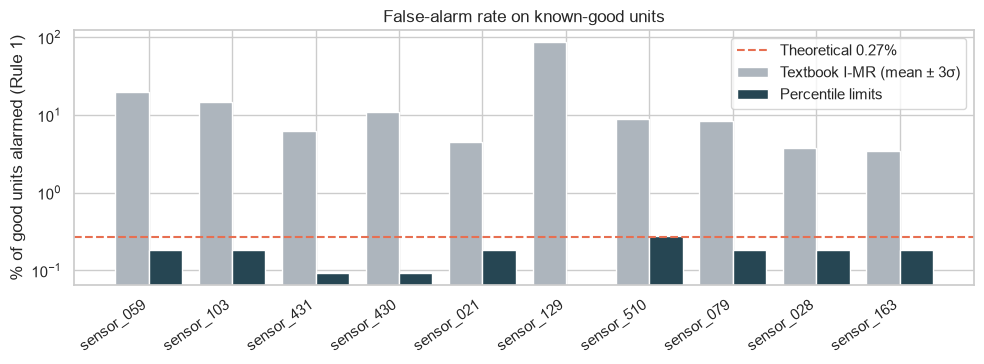

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(monitored))
ax.bar(x - 0.2, imr["rule1"] * 100, 0.4, color="#adb5bd", label="Textbook I-MR (mean ± 3σ)")
ax.bar(x + 0.2, pct["rule1"] * 100, 0.4, color="#264653", label="Percentile limits")
ax.axhline(0.27, color=FAIL_C, ls="--", label="Theoretical 0.27%")
ax.set_xticks(x, monitored.index, rotation=35, ha="right")
ax.set(ylabel="% of good units alarmed (Rule 1)", title="False-alarm rate on known-good units")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_false_alarm_comparison.png", dpi=150)
plt.show()

**Result:** Rule 1 false alarms drop from **up to 87% to ≤0.3%**, matching theory.
Run rules R3/R4 still over-fire because of autocorrelation — a known limitation — so they are kept as
**shift/trend warnings** on the sensor, while **R1 + R2 raise an out-of-control alarm** on the unit.

## 2. Run monitoring on the full timeline

In [6]:
limits, units, events = run_spc()
limits[["rank", "sensor", "lcl", "center", "ucl", "alarm_rate_baseline",
        "alarm_rate_test_pass", "warning_rate_test_pass"]].style.format(
    {"lcl": "{:.4g}", "center": "{:.4g}", "ucl": "{:.4g}", "alarm_rate_baseline": "{:.1%}",
     "alarm_rate_test_pass": "{:.1%}", "warning_rate_test_pass": "{:.1%}"})

,rank,sensor,lcl,center,ucl,alarm_rate_baseline,alarm_rate_test_pass,warning_rate_test_pass
0,1,sensor_059,-20.64,1.224,63.22,1.8%,0.0%,6.2%
1,2,sensor_103,-0.01845,-0.0099,0.001563,0.9%,0.3%,10.9%
2,3,sensor_431,1.628,17.06,400,1.5%,1.9%,4.9%
3,4,sensor_430,1.309,10.39,400,1.3%,1.1%,2.7%
4,5,sensor_021,-6908,-5561,-1310,1.8%,0.0%,12.5%
5,6,sensor_129,-3.779,-0.1419,1.939,4.1%,5.7%,22.8%
6,7,sensor_510,5.595,48.56,396.5,0.7%,0.0%,7.6%
7,8,sensor_079,-0.04432,0.0028,0.09611,2.0%,2.7%,33.7%
8,9,sensor_028,59.93,68.59,76.95,1.0%,3.5%,35.3%
9,10,sensor_163,0.01028,0.118,0.9521,1.5%,0.3%,3.0%


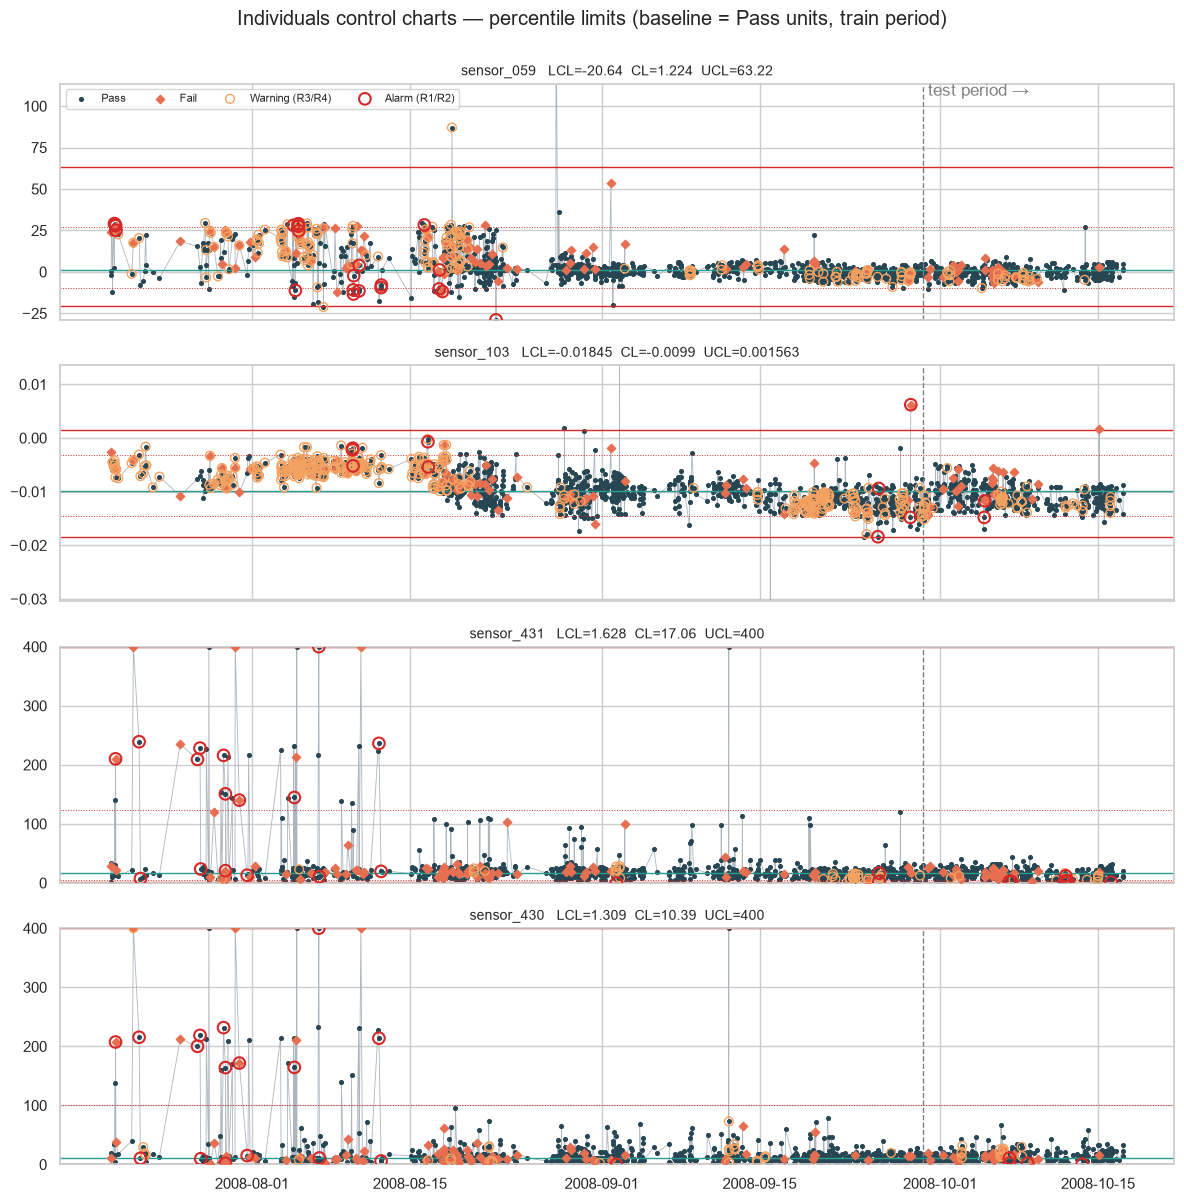

In [7]:
def control_chart(sensor, ax, lim=None):
    lim = lim or PercentileLimits.fit(baseline[sensor], sensor)
    f = western_electric(df[sensor], lim)
    t, v = df["timestamp"], df[sensor]
    ax.plot(t, v, color="#adb5bd", lw=0.6, zorder=1)
    ax.scatter(t[df.fail == 0], v[df.fail == 0], s=7, color="#264653", label="Pass", zorder=2)
    ax.scatter(t[df.fail == 1], v[df.fail == 1], s=18, color=FAIL_C, marker="D", label="Fail", zorder=3)
    ax.scatter(t[f.warning & ~f.alarm], v[f.warning & ~f.alarm], s=40, facecolors="none",
               edgecolors=WARN_C, label="Warning (R3/R4)", zorder=4)
    ax.scatter(t[f.alarm], v[f.alarm], s=70, facecolors="none", edgecolors=ALARM_C, lw=1.5,
               label="Alarm (R1/R2)", zorder=5)
    for k, ls in [(3, "-"), (2, ":"), (-2, ":"), (-3, "-")]:
        ax.axhline(lim.level(k), color=ALARM_C, ls=ls, lw=1 if abs(k) == 3 else 0.7)
    ax.axhline(lim.center, color=PASS_C, lw=1)
    ax.axvline(test_start, color="grey", ls="--", lw=1)
    lo, hi = lim.level(-3), lim.level(3)
    pad = (hi - lo) * 0.6
    ax.set_ylim(max(v.min(), lo - pad), min(v.max(), hi + pad))
    ax.set_title(f"{sensor}   LCL={lo:.4g}  CL={lim.center:.4g}  UCL={hi:.4g}", fontsize=10)
    return f

top4 = monitored.index[:4]
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
for s, ax in zip(top4, axes):
    control_chart(s, ax)
axes[0].legend(ncol=4, loc="upper left", fontsize=8)
axes[0].text(test_start, axes[0].get_ylim()[1], " test period →", color="grey", va="top")
fig.suptitle("Individuals control charts — percentile limits (baseline = Pass units, train period)", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_control_charts_top4.png", dpi=150, bbox_inches="tight")
plt.show()

Reading the charts: the green line is the baseline median, the red lines are the ±3σ-equivalent control limits
(dotted: ±2σ). Red circles are alarms, orange circles are shift/trend warnings, and diamonds are units that failed the final test.
The y-axis is clipped around the limits, so extreme spikes sit at the edge.

## 3. Violations by rule and over time

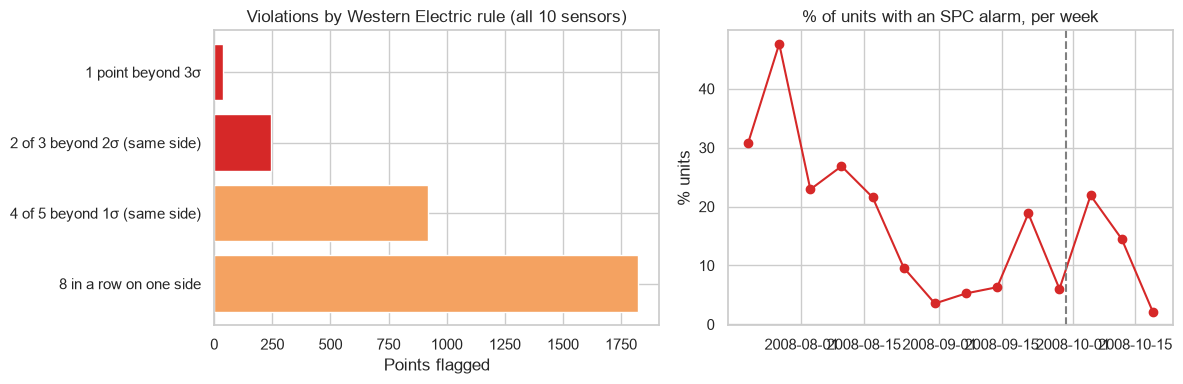

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_rule = pd.Series({RULE_NAMES[r]: limits[f"{r}_count"].sum() for r in RULES})
axes[0].barh(by_rule.index[::-1], by_rule.values[::-1], color=[WARN_C, WARN_C, ALARM_C, ALARM_C])
axes[0].set(title="Violations by Western Electric rule (all 10 sensors)", xlabel="Points flagged")

alarms = events[events.severity == "alarm"].set_index("timestamp").resample("W")["unit_id"].nunique()
volume = df.set_index("timestamp").resample("W")["unit_id"].count()
rate = (alarms.reindex(volume.index, fill_value=0) / volume * 100)[volume > 0]
axes[1].plot(rate.index, rate.values, marker="o", color=ALARM_C)
axes[1].axvline(test_start, color="grey", ls="--")
axes[1].set(title="% of units with an SPC alarm, per week", ylabel="% units")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_violations_summary.png", dpi=150)
plt.show()

## 4. Do SPC alarms predict failure?

In [9]:
eff = alarm_effectiveness(units)
eff["spc_alarm"] = eff["spc_alarm"].map({True: "Alarm", False: "No alarm"})
display(eff.style.format({"fail_rate": "{:.1%}"}))

test_u = units[units.period == "test"]
lift = test_u.loc[test_u.spc_alarm, "fail"].mean() / test_u.loc[~test_u.spc_alarm, "fail"].mean()
caught = test_u.loc[test_u.fail == 1, "spc_alarm"].mean()
print(f"Test period: alarmed units fail {lift:.1f}x as often; SPC alarms catch {caught:.0%} of failures.")

,period,spc_alarm,units,fails,fail_rate
0,test,No alarm,333,19,5.7%
1,test,Alarm,59,5,8.5%
2,train,No alarm,1032,68,6.6%
3,train,Alarm,143,12,8.4%


Test period: alarmed units fail 1.5x as often; SPC alarms catch 21% of failures.


**Honest result:** alarmed units fail ~1.5× more often than non-alarmed units, but univariate SPC
catches only about **1 in 5 failures**. That fits notebook 01, where no single sensor separated Pass
from Fail.

➡️ SPC is the right tool for *process stability* (is a sensor drifting?), but *predicting yield* needs a
**multivariate** view: feature selection (Step 4), an ML model (Step 5) and Hotelling T² / Isolation Forest
anomaly detection (Step 6).

## 5. Case study — `sensor_140` excursion

In notebook 02 `sensor_140` showed the largest shift between train and test. It is not a monitored top-10
sensor, and that is the point: a monitoring system has to watch **stability**, not only the sensors that
predict yield.

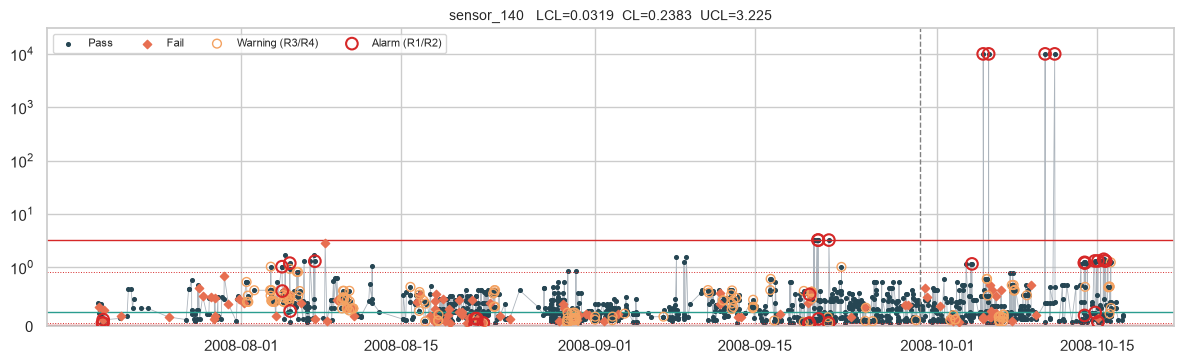

Baseline UCL = 3.225


,unit_id,timestamp,period,fail,sensor_140
1320,U1321,2008-10-05 12:03:00,test,0,9998.8944
1304,U1305,2008-10-05 00:33:00,test,0,9998.8795
1456,U1457,2008-10-11 06:56:00,test,0,9997.9792
1446,U1447,2008-10-10 10:46:00,test,0,9997.9106


In [10]:
s = "sensor_140"
fig, ax = plt.subplots(figsize=(12, 3.8))
f140 = control_chart(s, ax)
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 3e4)
ax.legend(ncol=4, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sensor140_excursion.png", dpi=150)
plt.show()

big = df.loc[f140.rule1, ["unit_id", "timestamp", "period", "fail", s]].sort_values(s, ascending=False)
lim140 = PercentileLimits.fit(baseline[s], s)
print(f"Baseline UCL = {lim140.ucl:.4g}")
big.head(8)

The extreme readings arrive in **October**, all read **≈ 9998–9999** (the baseline UCL is ≈ 3.2) and all
sit on units that **passed** the final test. A value stuck just under 10 000 looks like a **logging
placeholder / sensor error code**, not a physical measurement, so this is a **sensor or data-acquisition
fault**, not a process defect. In a fab this would trigger a *tool / metrology check*, not a scrap decision. Telling a
**sensor excursion** apart from a **yield excursion** is a key job of a quality intelligence platform.

## 6. Takeaways

| # | Finding | Why it matters |
|---|---|---|
| 1 | Textbook I-MR charts raise false alarms on 3–87% of good units | Real fab data breaks the normality and independence assumptions |
| 2 | Percentile limits bring Rule-1 false alarms down to ≤0.3% | The charts become usable; engineers trust the alarms |
| 3 | R3/R4 run rules over-fire on autocorrelated sensors | Kept as warnings, not alarms |
| 4 | SPC alarms raise fail risk ~1.5× but catch only ~1 in 5 failures | Motivates multivariate ML (Steps 4–6) |
| 5 | `sensor_140` October spikes are ≈ 9999 error-code values on *passing* units | Sensor fault vs real defect: route to metrology / tool maintenance |

**Outputs:** `data/processed/spc_limits.csv` (limits and zones per sensor), `spc_unit_alarms.csv` (per-unit alarm
counts), `spc_violations.csv` (every violation with its rule and severity) — ready for the dashboard.